<a href="https://colab.research.google.com/github/rc2308/churn-ensemble-engine/blob/main/notebooks/03_clustering_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Customer Segmentation (Stage 1)

**Goal:** Group customers into behavioral personas using K-Means clustering.
The cluster label becomes a feature for the churn model (Stage 2).

**Uses:** `src/data_prep.py`, `src/features.py`, `src/clustering.py`


In [1]:
import os
os.chdir("/content")
!rm -rf churn-ensemble-engine
!git clone https://github.com/rc2308/churn-ensemble-engine.git
%cd churn-ensemble-engine
!pip install -q -r requirements.txt


Cloning into 'churn-ensemble-engine'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 29 (delta 10), reused 24 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 5.65 KiB | 1.13 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/churn-ensemble-engine
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.7 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()   # select BankChurners.csv


Saving BankChurners.csv to BankChurners.csv


In [3]:
import pandas as pd
from src.data_prep import load_data, clean_data
from src.features import engineer_features, encode_categoricals

# Rebuild the pipeline
df = load_data("BankChurners.csv")
df = clean_data(df)
df = engineer_features(df)
df_encoded = encode_categoricals(df)

print("Encoded shape:", df_encoded.shape)
df_encoded.head()


Encoded shape: (10127, 35)


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,45,3,39,5,1,3,12691.0,777,11914.0,1.335,...,False,False,False,True,False,False,False,False,False,False
1,49,5,44,6,1,2,8256.0,864,7392.0,1.541,...,True,False,False,False,False,True,False,False,False,False
2,51,3,36,4,1,0,3418.0,0,3418.0,2.594,...,False,False,False,False,True,False,False,False,False,False
3,40,4,34,3,4,1,3313.0,2517,796.0,1.405,...,False,True,False,False,False,True,False,False,False,False
4,40,3,21,5,1,0,4716.0,0,4716.0,2.175,...,False,False,False,True,False,False,False,False,False,False


In [4]:
# Behavioral features that define customer personas
clust_feats = [
    "Customer_Age",
    "Credit_Limit",
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Avg_Utilization_Ratio",
    "Months_Inactive_12_mon",
    "Total_Relationship_Count",
    "Amt_per_Transaction"
]

print("Clustering on these features:")
print(clust_feats)
df_encoded[clust_feats].describe()


Clustering on these features:
['Customer_Age', 'Credit_Limit', 'Total_Trans_Ct', 'Total_Trans_Amt', 'Avg_Utilization_Ratio', 'Months_Inactive_12_mon', 'Total_Relationship_Count', 'Amt_per_Transaction']


,Customer_Age,Credit_Limit,Total_Trans_Ct,Total_Trans_Amt,Avg_Utilization_Ratio,Months_Inactive_12_mon,Total_Relationship_Count,Amt_per_Transaction
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,8631.953698,64.858695,4404.086304,0.274894,2.341167,3.812580,61.573946
std,8.016814,9088.776650,23.472570,3397.129254,0.275691,1.010622,1.554408,26.244708
min,26.000000,1438.300000,10.000000,510.000000,0.000000,0.000000,1.000000,18.813559
25%,41.000000,2555.000000,45.000000,2155.500000,0.023000,2.000000,3.000000,46.509259
50%,46.000000,4549.000000,67.000000,3899.000000,0.176000,2.000000,4.000000,54.857143
75%,52.000000,11067.500000,81.000000,4741.000000,0.503000,3.000000,5.000000,64.327076
max,73.000000,34516.000000,139.000000,18484.000000,0.999000,6.000000,6.000000,188.056180


In [5]:
from src.features import scale_for_clustering

scaled, scaler = scale_for_clustering(df_encoded, clust_feats)
print("Scaled shape:", scaled.shape)
print("Scaled means (should be ~0):", scaled.mean(axis=0).round(2))


Scaled shape: (10127, 8)
Scaled means (should be ~0): [ 0.  0. -0. -0. -0.  0. -0. -0.]


In [6]:
from src.clustering import find_optimal_k

results = find_optimal_k(scaled, k_range=range(2, 8))

# Display results
for k, metrics in results.items():
    print(f"K={k}: inertia={metrics['inertia']:.0f}, "
          f"silhouette={metrics['silhouette']:.3f}")


K=2: inertia=60425, silhouette=0.364
K=3: inertia=51161, silhouette=0.192
K=4: inertia=46825, silhouette=0.179
K=5: inertia=43169, silhouette=0.167
K=6: inertia=40240, silhouette=0.166
K=7: inertia=37907, silhouette=0.165


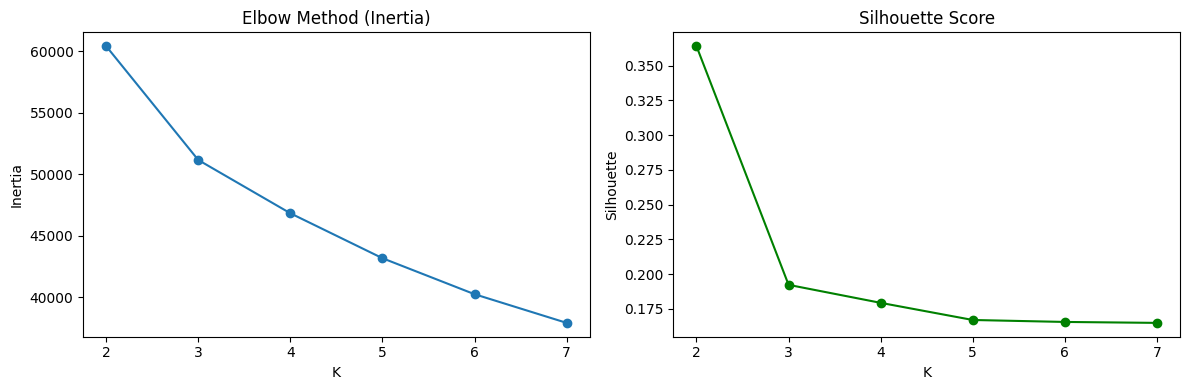

In [8]:
import matplotlib.pyplot as plt

ks = list(results.keys())
inertias = [results[k]["inertia"] for k in ks]
sils = [results[k]["silhouette"] for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
ax1.plot(ks, inertias, marker="o")
ax1.set_title("Elbow Method (Inertia)")
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia")

# Silhouette plot
ax2.plot(ks, sils, marker="o", color="green")
ax2.set_title("Silhouette Score")
ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette")

plt.tight_layout()
plt.savefig("reports/figures/optimal_k.png", bbox_inches="tight", dpi=150)
plt.show()


In [9]:
from src.clustering import fit_kmeans, assign_clusters

CHOSEN_K = 4   # ← change based on your Elbow/Silhouette results

km = fit_kmeans(scaled, k=CHOSEN_K)
cluster_labels = assign_clusters(km, scaled)

# How many customers in each cluster?
import numpy as np
unique, counts = np.unique(cluster_labels, return_counts=True)
print("Cluster sizes:")
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} customers")


Cluster sizes:
  Cluster 0: 3246 customers
  Cluster 1: 1338 customers
  Cluster 2: 4327 customers
  Cluster 3: 1216 customers


In [10]:
from src.clustering import profile_clusters

profile = profile_clusters(df_encoded, cluster_labels, clust_feats)
profile


,Customer_Age,Credit_Limit,Total_Trans_Ct,Total_Trans_Amt,Avg_Utilization_Ratio,Months_Inactive_12_mon,Total_Relationship_Count,Amt_per_Transaction
Cluster,,,,,,,,
0,46.472274,2720.207640,64.433457,3618.876155,0.623612,2.329328,4.046519,54.456660
1,45.434230,14119.485800,98.662182,11821.336323,0.163387,2.254858,2.204783,118.083185
2,46.384100,6384.938086,56.934828,3064.936214,0.112167,2.385486,4.032124,52.077315
3,46.709704,26370.478618,56.995066,3103.933388,0.045759,2.310033,4.175987,52.186830


In [11]:
# Add cluster + churn to profile
df_encoded_copy = df_encoded.copy()
df_encoded_copy["Cluster"] = cluster_labels

# Churn rate per cluster
churn_by_cluster = df_encoded_copy.groupby("Cluster")["Churn"].mean()
print("Churn rate per cluster:")
print(churn_by_cluster.round(3))

# ← AFTER reading the profile table, name your personas:
persona_map = {
    0: "Persona_0_name",   # <-- replace based on profile
    1: "Persona_1_name",
    2: "Persona_2_name",
    3: "Persona_3_name"
}
print("\nPersona map:", persona_map)


Churn rate per cluster:
Cluster
0    0.080
1    0.141
2    0.230
3    0.149
Name: Churn, dtype: float64

Persona map: {0: 'Persona_0_name', 1: 'Persona_1_name', 2: 'Persona_2_name', 3: 'Persona_3_name'}


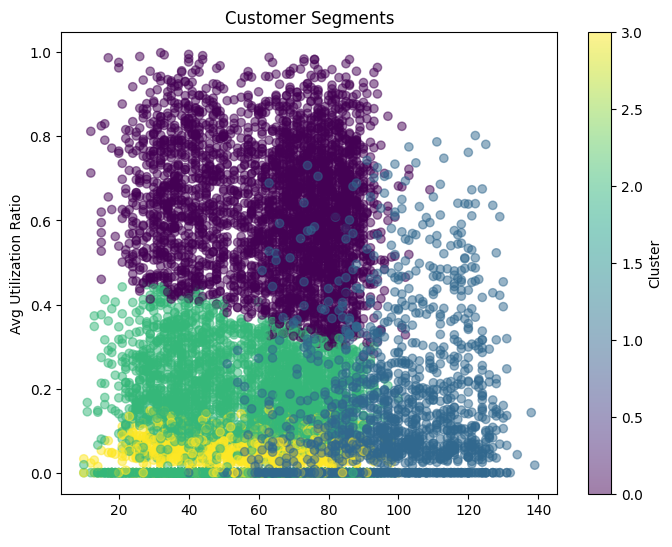

In [12]:
# Plot two key features colored by cluster
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_encoded["Total_Trans_Ct"],
    df_encoded["Avg_Utilization_Ratio"],
    c=cluster_labels, cmap="viridis", alpha=0.5
)
plt.xlabel("Total Transaction Count")
plt.ylabel("Avg Utilization Ratio")
plt.title("Customer Segments")
plt.colorbar(scatter, label="Cluster")
plt.savefig("reports/figures/clusters_2d.png", bbox_inches="tight", dpi=150)
plt.show()


## Segmentation Results

Chose **K = 4** based on Elbow + Silhouette (silhouette favored K=2, but K=4
chosen for business interpretability).

| Cluster | Persona Name | Key Traits | Size | Churn Rate |
|---------|-------------|-----------|------|------------|
| 0 | Engaged Revolvers | High utilization, moderate activity | 3,246 | 8.0% |
| 1 | Active Transactors | Highest transactions, low utilization | 1,338 | 14.1% |
| 2 | At-Risk Average Users | Low-mid activity, largest group | 4,327 | 23.0% |
| 3 | Dormant / Inactive | Near-zero utilization, low activity | 1,216 | 14.9% |

**Insight:** Cluster 2 (At-Risk Average Users) churns at 23% — nearly 3× the
rate of Cluster 0 (8%). As the largest segment, it is the top priority for
targeted retention campaigns.

